# 4. Regression - Naive Baseline (Persistence Model)

**Task**: Predict next-hour Garman–Klass (GK) volatility (`target_reg`)  

**Baseline strategy**: Persistence model to predict that next hour's volatility equals the current hour's volatility  

$$
\hat{y}_{t+1} = \text{gk\_volatility}_t
$$

**Why this matters**: GK volatility has a lag-1 autocorrelation of 0.649 and it is persistent. Any real model must beat this baseline to justify its complexity.

**Metrics**: RMSE, MAE, R²  

**Results saved to**: `results/regression_results.csv`

## 1. Imports & Setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_FILE = os.path.join(BASE_DIR, 'data', 'cleaned_data_with_dual_targets.csv')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Libraries loaded.")
print(f"Base dir  : {BASE_DIR}")
print(f"Data file : {DATA_FILE}")
print(f"Results   : {RESULTS_DIR}")

Libraries loaded.
Base dir  : /Users/mihiniboteju/cryptoflow
Data file : /Users/mihiniboteju/cryptoflow/data/cleaned_data_with_dual_targets.csv
Results   : /Users/mihiniboteju/cryptoflow/results


## 2. Load Data & Apply Same 85/15 Split

We load `cleaned_data_with_dual_targets.csv` which contains both `gk_volatility` and `target_reg` (next hour's GK volatility).  
The split index must match exactly what was used in Phase 3 preprocessing.

In [4]:
df = pd.read_csv(DATA_FILE, parse_dates=['open time'])

# Drop rows that have NaN in the columns we need
df = df.iloc[24:].reset_index(drop=True)

# Temporal 85/15 split — same index as Phase 3
split_index = int(len(df) * 0.85)
test_df = df.iloc[split_index:].copy()

print(df.isna().any().any())

print(f"Total rows after NaN drop : {len(df):,}")
print(f"Split index               : {split_index:,}")
print(f"Test rows                 : {len(test_df):,}")
print(f"Test date range           : {test_df['open time'].min()} - {test_df['open time'].max()}")
print()
print("gk_volatility (current) vs target_reg (next hour):")
print(df[['open time', 'gk_volatility', 'target_reg']].head(5).to_string(index=False))

False
Total rows after NaN drop : 70,895
Split index               : 60,260
Test rows                 : 10,635
Test date range           : 2024-11-16 20:00:00 → 2026-02-02 22:00:00

gk_volatility (current) vs target_reg (next hour):
          open time  gk_volatility  target_reg
2018-01-02 00:00:00       0.017503    0.007614
2018-01-02 01:00:00       0.007614    0.014051
2018-01-02 02:00:00       0.014051    0.014333
2018-01-02 03:00:00       0.014333    0.029853
2018-01-02 04:00:00       0.029853    0.008089


## 3. Persistence Model (Naive Baseline)

**Prediction rule**: $\hat{y}_{t+1} = \text{gk\_volatility}_t$  
No training just use the current hour's volatility as the prediction for the next hour.

In [11]:
# --- Persistence Model ---
y_true = test_df['target_reg'].values
y_pred = test_df['gk_volatility'].values
print("y_true (target_reg — next hour) :", y_true[:5])
print("y_pred (gk_volatility — now)    :", y_pred[:5])
print("Diff (first 5)                  :", (y_true - y_pred)[:5])

# --- Metrics (scratch) ---
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

rmse_val = rmse(y_true, y_pred)
mae_val  = mae(y_true, y_pred)
r2_val   = r2(y_true, y_pred)

# with sklearn
rmse_sk = np.sqrt(mean_squared_error(y_true, y_pred))
mae_sk  = mean_absolute_error(y_true, y_pred)
r2_sk   = r2_score(y_true, y_pred)

print("=" * 50)
print("  REGRESSION NAIVE BASELINE — PERSISTENCE MODEL")
print("=" * 50)
print(f"  RMSE  (scratch)  : {rmse_val:.6f}")
print(f"  RMSE  (sklearn)  : {rmse_sk:.6f}")
print(f"  MAE   (scratch)  : {mae_val:.6f}")
print(f"  MAE   (sklearn)  : {mae_sk:.6f}")
print(f"  R²    (scratch)  : {r2_val:.4f}")
print(f"  R²    (sklearn)  : {r2_sk:.4f}")
print("=" * 50)
print("All real regression models must achieve lower RMSE and higher R² than this.")

y_true (target_reg — next hour) : [0.00231647 0.00300415 0.00180385 0.00190764 0.00577838]
y_pred (gk_volatility — now)    : [0.00318432 0.00231647 0.00300415 0.00180385 0.00190764]
Diff (first 5)                  : [-0.00086785  0.00068768 -0.00120031  0.00010379  0.00387074]
  REGRESSION NAIVE BASELINE — PERSISTENCE MODEL
  RMSE  (scratch)  : 0.002810
  RMSE  (sklearn)  : 0.002810
  MAE   (scratch)  : 0.001600
  MAE   (sklearn)  : 0.001600
  R²    (scratch)  : 0.1851
  R²    (sklearn)  : 0.1851
All real regression models must achieve lower RMSE and higher R² than this.


## 4. Visualization: Predicted vs Actual

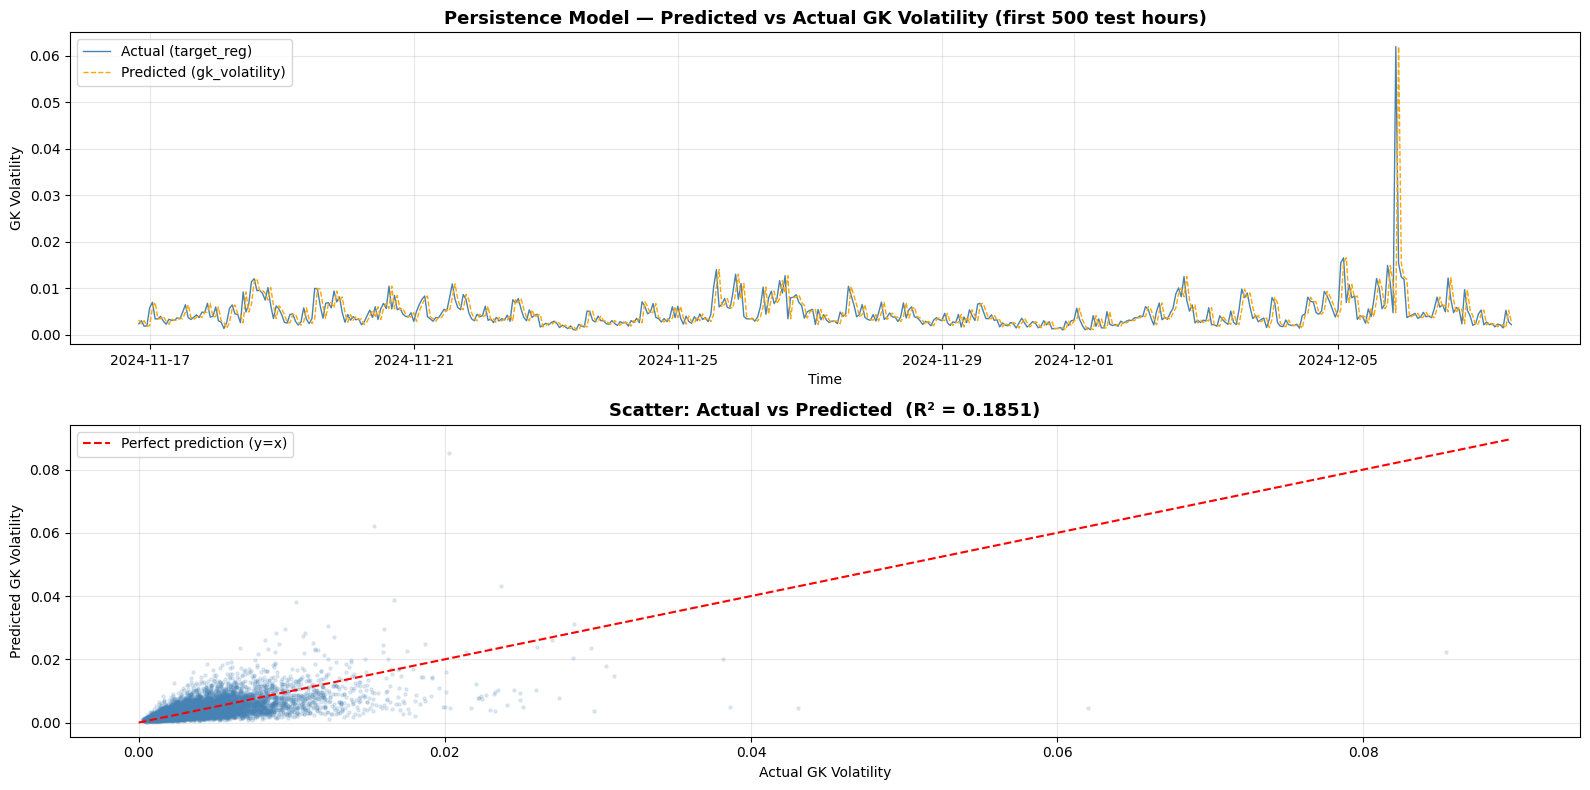

Plot saved: /Users/mihiniboteju/cryptoflow/plots/reg_naive_baseline_persistence.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Plot 1: time series: first 500 test points for readability
n = 500
axes[0].plot(test_df['open time'].values[:n], y_true[:n],
             label='Actual (target_reg)', color='steelblue', linewidth=1)
axes[0].plot(test_df['open time'].values[:n], y_pred[:n],
             label='Predicted (gk_volatility)', color='orange', linewidth=1, linestyle='--')
axes[0].set_title('Persistence Model — Predicted vs Actual GK Volatility (first 500 test hours)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('GK Volatility')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: scatter
axes[1].scatter(y_true, y_pred, alpha=0.15, s=5, color='steelblue')
lim = max(y_true.max(), y_pred.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction (y=x)')
axes[1].set_title(f'Scatter: Actual vs Predicted  (R² = {r2_val:.4f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual GK Volatility')
axes[1].set_ylabel('Predicted GK Volatility')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'reg_naive_baseline_persistence.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved: {plot_path}")

## 5. Save Results to `results/regression_results.csv`

In [13]:
results_path = os.path.join(RESULTS_DIR, 'regression_results.csv')

new_row = pd.DataFrame([{
    'model'      : 'Persistence Baseline',
    'rmse'       : round(rmse_val, 6),
    'mae'        : round(mae_val, 6),
    'r2'         : round(r2_val, 4),
    'notes'      : 'Naive baseline: y_hat(t+1) = gk_volatility(t). No training.'
}])

# Append if file exists, else create fresh
if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    combined = pd.concat([existing, new_row], ignore_index=True)
    combined.to_csv(results_path, index=False)
else:
    new_row.to_csv(results_path, index=False)

print(f"Results saved to: {results_path}")
print()
print(pd.read_csv(results_path).to_string(index=False))

Results saved to: /Users/mihiniboteju/cryptoflow/results/regression_results.csv

               model    rmse    mae     r2                                                       notes
Persistence Baseline 0.00281 0.0016 0.1851 Naive baseline: y_hat(t+1) = gk_volatility(t). No training.
